![logo](../../../LogoLine_horizon_C3S.png)

<div class="alert alert-block alert-warning">
Please note that this repository is used for development and review, so quality assessments should be considered work in progress until they are merged into the main branch
</div>

# Sea ice drift from satellite observations: spatio-temporal coverage and consistency of Antarctic sea ice drift for variability and trend assessments

Production date: 30-04-2026

Dataset version: 1.0

Produced by: Yoni Verhaegen and Philippe Huybrechts (Vrije Universiteit Brussel)

## 🌍 Use case: Variability and trend assessment of Antarctic sea ice transport 

## ❓ Quality assessment question
* **"Is the spatial and temporal coverage of the C3S sea ice drift dataset sufficiently adequate to capture the spatio-temporal variability and trends of Antarctic sea ice motion?"**

Satellite observations provide an essential means of monitoring the motion of sea ice and its role in the redistribution of ice across the polar oceans. Sea ice drift strongly influences the transport of freshwater and is therefore a key component of the polar climate system. Understanding variability and potential trends in sea ice transport requires datasets that provide sufficient spatial and temporal coverage as well as consistent retrievals over multi-decadal periods. In this context, the ‘Sea ice drift daily gridded data derived from satellite observations’ on the Climate Data Store (CDS), provided by the Ocean and Sea Ice Satellite Application Facility (OSI SAF), offers daily sea ice drift vectors and their associated uncertainties for both hemispheres on a 75 km equal area projection grid. They can be interpreted as sea ice motion: the displacement of sea ice within a certain time period [[1](https://doi.org/10.5194/essd-15-5807-2023)].

The sea ice drift dataset offers winter season satellite-derived estimates, supplemented with model data during the summer months, of sea ice motion and therefore offers valuable data for investigating large-scale sea ice circulation patterns. However, before such a dataset can be used for variability and trend assessments, its suitability must be evaluated in terms of its spatio-temporal coverage and consistency. This assessment therefore examines whether the C3S sea ice drift dataset provides adequate coverage and consistency to be able to conduct an analyses of variability and trends of sea ice transport. For that, we use the dataset version 1.0 on the CDS and specifically focus on the Antarctic region. The Antarctic region was selected for this analysis primarily because sea ice dynamics there are more prominently shaped by clear patterns of oceanic and atmospheric forcing, as the Southern Ocean exhibits a more symmetric circulation (e.g. the Antarctic Circumpolar Current). This simplifies the interpretation of drift patterns and trends.

🚨 **Although this notebook deals with the Antarctic sea ice only, sea ice drift data for the Arctic region are also available.**

## 📢 Quality assessment statements

```{admonition} These are the key outcomes of this assessment
:class: note

- The C3S sea ice drift product offers daily sea ice drift vectors for both hemispheres on a 75 km equal-area projection grid and also includes pixel-level quality flags, as well as quantitative uncertainty estimates. An uncertainty (through the magnitude of the provided errors) and spatio-temporal coverage (through the use of quality flags) analysis reveals that the degree of valid pixel retrievals is higher during the winter months and over robust, closed sea ice. In contrast, uncertainty shows poorer data quality (i.e. higher values) at the margins and during the summer season. The provided quality flags thus capture these limitations, enabling users to filter the data according to their use case.
- With respect to the use case, the C3S sea ice drift product is found to be suitable to derive variability and (potential) trends of Antarctic sea ice motion, as (1) quality and rejection flags are available to eliminate lesser quality data if desired, (2) the temporal resolution is consistent at daily spaced intervals, and (3) the number of years (since 1991) is sufficient to detect reliable temporal signals and is also compliant with the minimum WMO requirement of 30 years for change detection. However, when interpreting these signals, users should keep in mind that data during the summer months and over pixels that are close to the coast or sea ice edge (for which data acquisition using satellites is difficult) should be handled with care.

## 📋 Methodology

### Dataset description

The C3S OSI SAF product combines data from (1) multiple microwave radiometers using feature-tracking techniques to estimate the displacement of sea ice patterns between consecutive satellite images in the winter season, and (2) model-driven sea ice drift fields using ERA5 10 m wind data and a tuned free-drift model in the summer season. The corresponding displacements are converted into drift vectors representing sea ice motion over the time interval between satellite images. Post-processing involves, amongst others, gap-filling by interpolation. To ensure temporal consistency, data from different sensors are homogenized and merged into a continuous data record covering several decades (1991-2020). The dataset provides the zonal and meridional components of sea ice drift on an equal area projection grid, as well as their uncertainty estimates (provided as 1-sigma errors). Data are delivered in NetCDF format and include additional relevant information such as rejection and quality flags. All data follow a consistent projection with drift values expressed in km per day [[1](https://doi.org/10.5194/essd-15-5807-2023)]. 

### Structure and (sub)sections

**[](satellite_satellite-sea-ice-drift_uncertainty-quality-flags_q02:section-1)**

* [](satellite_satellite-sea-ice-drift_uncertainty-quality-flags_q02:section-1-1)
* [](satellite_satellite-sea-ice-drift_uncertainty-quality-flags_q02:section-1-2)
* [](satellite_satellite-sea-ice-drift_uncertainty-quality-flags_q02:section-1-3)
  
**[](satellite_satellite-sea-ice-drift_uncertainty-quality-flags_q02:section-2)**
* [](satellite_satellite-sea-ice-drift_uncertainty-quality-flags_q02:section-2-1)
* [](satellite_satellite-sea-ice-drift_uncertainty-quality-flags_q02:section-2-2)

**[](satellite_satellite-sea-ice-drift_uncertainty-quality-flags_q02:section-3)**
* [](satellite_satellite-sea-ice-drift_uncertainty-quality-flags_q02:section-3-1)
* [](satellite_satellite-sea-ice-drift_uncertainty-quality-flags_q02:section-3-2)

**[](satellite_satellite-sea-ice-drift_uncertainty-quality-flags_q02:section-4)**
* [](satellite_satellite-sea-ice-drift_uncertainty-quality-flags_q02:section-4-1)
* [](satellite_satellite-sea-ice-drift_uncertainty-quality-flags_q02:section-4-2)

**[](satellite_satellite-sea-ice-drift_uncertainty-quality-flags_q02:section-5)**

## 📈 Analysis and results

(satellite_satellite-sea-ice-drift_uncertainty-quality-flags_q02:section-1)=
### 1. Data preparation and processing

(satellite_satellite-sea-ice-drift_uncertainty-quality-flags_q02:section-1-1)=
#### 1.1 Import packages

First we load the packages:

In [39]:
from c3s_eqc_automatic_quality_control import download, utils, diagnostics
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import xarray as xr
import pandas as pd
import os
from scipy.stats import linregress
from matplotlib.colors import ListedColormap
import warnings
warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-notebook")

(satellite_satellite-sea-ice-drift_uncertainty-quality-flags_q02:section-1-2)=
#### 1.2 Define request and download

Then we define the parameters, i.e. for which years the data should be downloaded:

In [26]:
year_start = 1991
year_stop = 2020

Then we define requests for download from the CDS and download and transform the sea ice data. We resample the data from daily to monthly values to decrease the data size:

In [27]:
time_request = {
    "year": [str(year) for year in range(year_start, year_stop + 1)],
    "month": [f"{month:02d}" for month in range(1, 13)],
}

requests = {
    "satellite-sea-ice-drift": time_request
    | {
        "variable": "all",
        "region": "southern_hemisphere",
        "day": [f"{day:02d}" for day in range(1, 32)],
        "version": "1_0",
    },
    "satellite-sea-ice-concentration": time_request
    | {
        "variable": "all",
        "sensor": "ssmis",
        "region": ["southern_hemisphere"],
        "cdr_type": ["cdr"],
        "temporal_aggregation": "monthly",
        "version": "3_1",
    },
}

Here, we define a function that resamples all data to monthly averaged data, except for the `status_flag` variable:

In [28]:
def compute_valid_fraction(da):
    return (da == 30).sum("time") / da.sizes["time"]
def compute_rejected_fraction(da):
    return ((da >= 0) & (da < 20)).sum("time") / da.sizes["time"]
def compute_lessquality_fraction(da):
    return ((da >= 20) & (da < 30)).sum("time") / da.sizes["time"]

def resample_and_add_valid_fraction(ds, freq):
    valid_fraction = ds["status_flag"].resample(time=freq).map(compute_valid_fraction)
    valid_fraction.attrs = {"long_name": "Fraction of valid data"}
    rejected_fraction = ds["status_flag"].resample(time=freq).map(compute_rejected_fraction)
    rejected_fraction.attrs = {"long_name": "Fraction of rejected data"}
    lessquality_fraction = ds["status_flag"].resample(time=freq).map(compute_lessquality_fraction)
    lessquality_fraction.attrs = {"long_name": "Fraction of less quality data"}

    ds = ds.resample(time=freq).mean(keep_attrs=True)
    ds["valid_fraction"] = valid_fraction
    ds["rejected_fraction"] = rejected_fraction
    ds["lessquality_fraction"] = lessquality_fraction
    return ds

Finally, we download the data and apply the transformation function:

In [29]:
datasets = []
for collection_id, request in requests.items():
    if collection_id == "satellite-sea-ice-drift":
        transform_func = resample_and_add_valid_fraction
        transform_func_kwargs = {"freq": "1MS"}
    else:
        transform_func = None
        transform_func_kwargs = {}

    print(f"{collection_id = }")
    ds = download.download_and_transform(
        collection_id,
        request,
        chunks={"year": 1},
        transform_func=transform_func,
        transform_func_kwargs=transform_func_kwargs,
    )
    if collection_id == "satellite-sea-ice-concentration":
        ds = ds.isel(xc=slice(1, None, 3), yc=slice(1, None, 3))
        ds["time"] = ds["time"].dt.strftime("%Y-%m-01").astype("datetime64[ns]")
    datasets.append(ds)

with xr.set_options(use_new_combine_kwarg_defaults=True):
    ds = xr.merge(datasets)

collection_id = 'satellite-sea-ice-drift'


100%|██████████| 30/30 [00:02<00:00, 10.04it/s]


collection_id = 'satellite-sea-ice-concentration'


100%|██████████| 30/30 [00:01<00:00, 19.36it/s]


(satellite_satellite-sea-ice-drift_uncertainty-quality-flags_q02:section-1-3)=
#### 1.3 Display and inspect data

We can read and inspect the data. Let us print out the data to inspect its structure:

In [30]:
ds_sea_ice_drift = datasets[0]
ds_display = ds_sea_ice_drift.drop_vars(["valid_fraction","rejected_fraction","lessquality_fraction"]) # Drop the manually calculated variables for display
ds_display

<xarray.Dataset> Size: 329MB
Dimensions:                       (time: 360, yc: 144, xc: 144)
Coordinates:
  * time                          (time) datetime64[ns] 3kB 1991-01-01 ... 20...
  * yc                            (yc) float64 1kB 5.362e+03 ... -5.362e+03
  * xc                            (xc) float64 1kB -5.362e+03 ... 5.362e+03
    latitude                      (yc, xc) float32 83kB dask.array<chunksize=(144, 144), meta=np.ndarray>
    longitude                     (yc, xc) float32 83kB dask.array<chunksize=(144, 144), meta=np.ndarray>
Data variables:
    Lambert_Azimuthal_Equal_Area  (time) float64 3kB dask.array<chunksize=(12,), meta=np.ndarray>
    t0                            (time, yc, xc) datetime64[ns] 60MB dask.array<chunksize=(12, 144, 144), meta=np.ndarray>
    t1                            (time, yc, xc) datetime64[ns] 60MB dask.array<chunksize=(12, 144, 144), meta=np.ndarray>
    lat1                          (time, yc, xc) float32 30MB dask.array<chunksize=(12, 144, 144), meta=np.ndarray>
    lon1                          (time, yc, xc) float32 30MB dask.array<chunksize=(12, 144, 144), meta=np.ndarray>
    dX                            (time, yc, xc) float32 30MB dask.array<chunksize=(12, 144, 144), meta=np.ndarray>
    dY                            (time, yc, xc) float32 30MB dask.array<chunksize=(12, 144, 144), meta=np.ndarray>
    status_flag                   (time, yc, xc) float64 60MB dask.array<chunksize=(12, 144, 144), meta=np.ndarray>
    uncert_dX_and_dY              (time, yc, xc) float32 30MB dask.array<chunksize=(12, 144, 144), meta=np.ndarray>
Attributes: (12/42)
    title:                     Global Sea Ice Drift Climate Data Record Versi...
    summary:                   This climate data record of sea ice drift vect...
    topiccategory:             Oceans ClimatologyMeteorologyAtmosphere
    keywords:                  GCMDSK:Earth Science > Cryosphere > Sea Ice > ...
    keywords_vocabulary:       GCMDSK:GCMD Science Keywords:https://gcmd.eart...
    geospatial_lat_max:        -17.021584
    ...                        ...
    tracking_id:               fc94c6b1-de36-452d-8703-71036f9f5288
    naming_authority:          int.eumetsat
    Conventions:               CF-1.7,ACDD-1.3
    standard_name_vocabulary:  CF Standard Name Table (Version 78, 21 Septemb...
    product_name:              osi_saf_sea_ice_drift_climate_data_record
    doi:                       10.15770/EUM SAF OSI 0012

Here, the downloaded set of the C3S OSI SAF sea ice drift data provides daily (although we transformed them to monthly averages) satellite and model-derived sea ice drift vectors $D$ on a 75 km Lambert Azimuthal Equal Area grid covering the entire Antarctic. Sea ice drift components (`dX`, `dY`) are provided in grid coordinates together with corresponding latitude/longitude fields and uncertainty estimates (`uncert_dX_and_dY`). The total drift speed (and its direction) can be computed as the Euclidean norm of (dX, dY):

$D = \sqrt{D_x^2 + D_y^2}$

where $D_x$ and $D_y$ are the zonal and meridional components of the sea ice drift (in km/day) respectively, defined within the projected grid. A variable `status_flag` further indicates the quality of the data (see the [Product User Guide](https://osisaf-hl.met.no/sites/osisaf-hl/files/user_manuals/osisaf_cdop3_ss2_pum_sea-ice-drift-lr-cdr_v1p0.pdf)). A `status_flag` value of 30, for example, indicates vectors with valid quality (i.e. the vector is retrieved purely from satellite observations and independent of other vectors or the free-drift model). All other values for this variable indicate lesser data quality or rejected data.

(satellite_satellite-sea-ice-drift_uncertainty-quality-flags_q02:section-2)=
### 2. Patterns of Antarctic sea ice motion and its uncertainty

(satellite_satellite-sea-ice-drift_uncertainty-quality-flags_q02:section-2-1)=
#### 2.1 Average sea ice drift velocities

We begin by plotting the sea ice drift vectors averaged between the beginning and end period that we selected for the sea ice drift data with a defined plotting function (i.e. in this case 1991-2020). Let us therefore first define a plotting function that uses the displacement components `dX` and `dY` to define a vector field:

In [31]:
def plot_mean_drift_arrows(ds, step=1, suptitle=None, cmap="rainbow", vmin=2, vmax=16, arrow_length=0.1):

    # Compute data to displace
    dX_mean = ds["dX"].mean(dim="time", skipna=True)
    dY_mean = ds["dY"].mean(dim="time", skipna=True)

    U = dX_mean[::step, ::step].values
    V = dY_mean[::step, ::step].values

    S = np.hypot(U, V)

    U = np.divide(U, S, out=np.zeros_like(U), where=S > 0)
    V = np.divide(V, S, out=np.zeros_like(V), where=S > 0)
    
    x = ds["xc"][::step].values*1000
    y = ds["yc"][::step].values*1000
    XX, YY = np.meshgrid(x, y)

    # Colormap 
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    cmap_obj = plt.colormaps[cmap]

    # Projection 
    proj = ccrs.LambertAzimuthalEqualArea(central_longitude=0, central_latitude=-90)

    fig, ax = plt.subplots(figsize=(7.5,7.5),
                           subplot_kw={"projection": proj})

    # Background land/ocean
    ax.add_feature(cfeature.OCEAN, facecolor="lightblue", zorder=0)
    ax.add_feature(cfeature.LAND, facecolor="0.9", edgecolor="black", zorder=1)
    ax.coastlines(linewidth=0.8, zorder=2)
    ax.gridlines(draw_labels=False, linewidth=0.4, linestyle="--",
                 color="gray", alpha=0.5)
    
    # Extent in lon/lat 
    ax.set_extent([-180, 180, -90, -52.5], crs=ccrs.PlateCarree())
    
    # Quiver
    q = ax.quiver(
        XX, YY, U, V, S,
        transform=proj,        
        cmap=cmap_obj,
        norm=norm,
        width=0.0025,
        headwidth=4,
        headlength=4,
        headaxislength=3,
        zorder=3,
        angles='uv',              
        scale_units='inches',     
        scale=1 / arrow_length,   
    )

    # Colorbar
    cb = fig.colorbar(q, ax=ax, shrink=0.65, pad=0.04, extend="both")
    cb.set_label("Mean drift speed (km/day)")

    # Add title
    ax.set_title("Mean sea ice drift vectors (D)", fontsize=14)
    if suptitle:
        fig.suptitle(suptitle, fontsize=16)

    # Plotting
    plt.tight_layout()
    plt.show()

The data are provided on a 75 km grid, which is slightly too coarse with respect to the GCOS threshold of 50 km [[3](https://gcos.wmo.int/site/global-climate-observing-system-gcos/essential-climate-variables)]. The plotting function reveals the following figure:

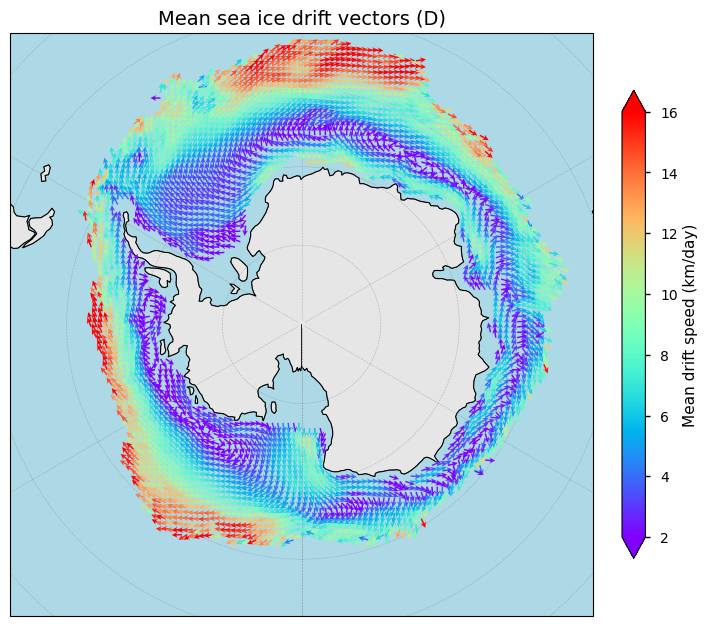

In [32]:
plot_mean_drift_arrows(ds_sea_ice_drift)

*Figure 1. Average sea ice drift vectors across the Antarctic region from the C3S data during the 1991-2020 period. It must be noted that the period over which the data are averaged in this figure may differ, depending on available data (e.g. due to seasonal sea ice extent variations or potential missing data).*

A notable feature in the image above is the presence of the Antarctic Circumpolar Current (ACC), which is an ocean current that flows clockwise (as seen from the South Pole) from west to east around Antarctica. Another feature is the eastward (counterclockwise) drift near the Antarctic coastal regions. Drift speeds are relatively slow near the coast and increase towards the outer sea ice edge, where the ice is more mobile and influenced by stronger winds and ocean currents. Regionally, the flow is modulated by large gyres such as the Weddell and Ross Sea circulations, which contribute to the export of sea ice away from Antarctica. The patterns agree well with independent assessments (e.g. [[2](https://data.meereisportal.de/eisatlas/)]). 

(satellite_satellite-sea-ice-drift_uncertainty-quality-flags_q02:section-2-2)=
#### 2.2 Sea ice drift uncertainty

Let us now investigate the uncertainties of the sea ice drift data. We therefore plot the reported uncertainties within `uncert_dX_and_dY`. The total error of a sea ice drift estimate is theoretically given by both a precision (random) and an accuracy (systematic) error. For the sea ice drift data, the product only deals with precision errors in the form of 1 standard deviation. In this case, the uncertainty can therefore be expressed as $\sigma_D$. Let us inspect the 2D field of these uncertainties to get an idea of the spatial variation:

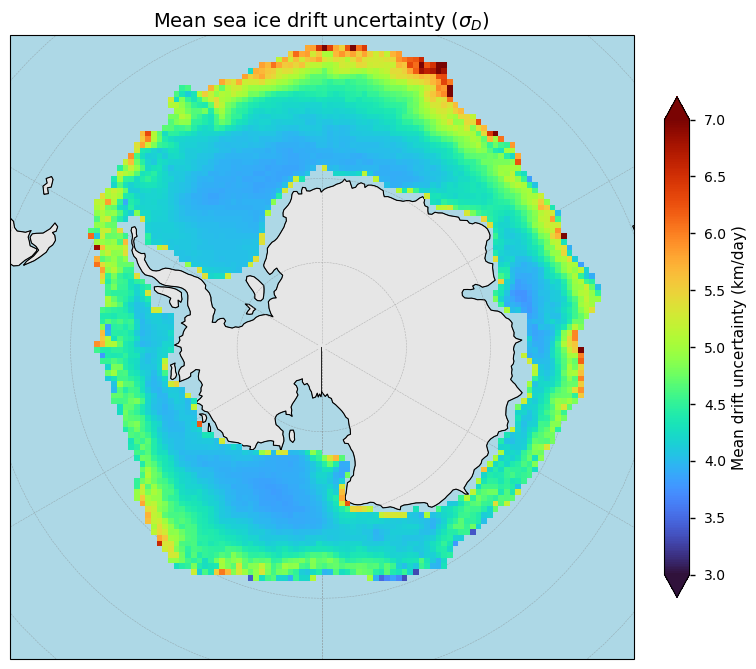

In [37]:
def plot_mean_field(ds, varname, title=None, cmap=None, vmin=None, vmax=None):

    # Time-mean field 
    da = ds[varname].mean(dim="time", skipna=True)

    # Coordinates (km to m)
    x = ds["xc"].values * 1000
    y = ds["yc"].values * 1000

    # Colormap 
    if vmin is None:
        vmin = float(da.min())
    if vmax is None:
        vmax = float(da.max())

    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    # Projection 
    proj = ccrs.LambertAzimuthalEqualArea(central_longitude=0, central_latitude=-90)

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": proj})

    # Extent in lon/lat 
    ax.set_extent([-180, 180, -90, -52.5], crs=ccrs.PlateCarree())

    # Background
    ax.add_feature(cfeature.OCEAN, facecolor="lightblue", zorder=0)
    ax.add_feature(cfeature.LAND, facecolor="0.9", edgecolor="black", zorder=1)
    ax.coastlines(linewidth=0.8, zorder=2)

    # Plot gridded field 
    im = ax.pcolormesh(
        x, y, da.values,
        cmap=cmap,
        norm=norm,
        transform=proj,
        shading="auto",
        zorder=3,
    )

    ax.gridlines(draw_labels=False, linewidth=0.4, linestyle="--",
                 color="gray", alpha=0.5, zorder=100)

    # Colorbar 
    cb = fig.colorbar(im, ax=ax, shrink=0.65, pad=0.04, extend='both')
    cb.set_label("Mean drift uncertainty (km/day)")

    # Title 
    if title is None:
        title = f"Mean {varname}"
    ax.set_title(title, fontsize=14)

    plt.tight_layout()
    plt.show()

plot_mean_field(
    ds_sea_ice_drift,
    varname="uncert_dX_and_dY",
    title=r"Mean sea ice drift uncertainty (${\sigma}_{D}$)",
    cmap="turbo",
    vmin=3,
    vmax=7
)

*Figure 2. Time-averaged sea ice drift uncertainty over the Antarctic region (1991-2020) from the C3S data.*

The above figure shows the spatial pattern of the time-averaged uncertainty related to the sea ice drift data over the Antarctic area (1991-2020). Uncertainties are lowest over closed sea ice, but clearly increase toward the margins and/or dynamically active export regions. Peak values therefore generally occur near the Antarctic coastal regions and near the sea ice edge. Let us plot some statistics (i.e. its minimum, maximum and average value) of the error variable over the entire domain and time period:

In [34]:
da = ds_sea_ice_drift['uncert_dX_and_dY']

mean_val = float(da.mean())
min_val  = float(da.min())
max_val  = float(da.max())

print(f"uncert_dX_and_dY -> 1991-2020 mean: {mean_val:.4f} km/day, min: {min_val:.4f} km/day, max: {max_val:.4f} km/day")

uncert_dX_and_dY -> 1991-2020 mean: 4.2224 km/day, min: 2.2854 km/day, max: 13.1641 km/day


This reveals that the overall error meets the GCOS threshold of 5 km/day (when expressed as 1-sigma precision errors) [[3](https://library.wmo.int/records/item/58111-the-2022-gcos-ecvs-requirements-gcos-245)]. Let us make a time series of these data to get an idea of the temporal variation:

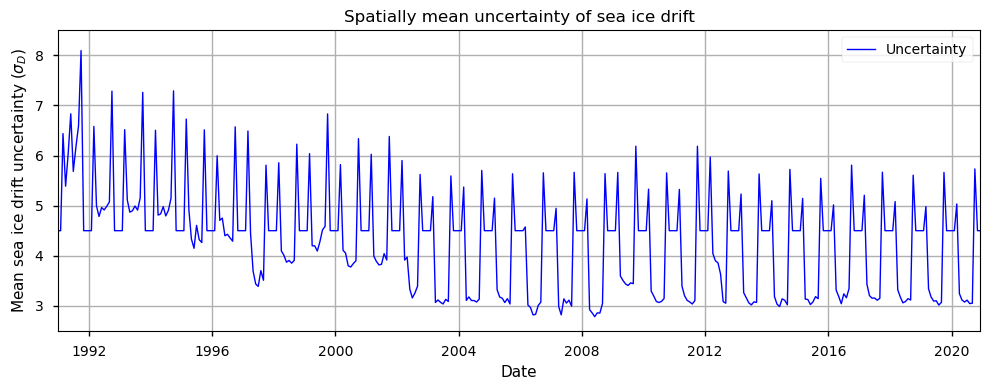

In [38]:
ice_conc_thres = 0.15

# Fraction of valid data
fraction_unc = (
    ds["uncert_dX_and_dY"].mean(dim=("yc", "xc")))

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(ds["time"], fraction_unc, lw=1, color="blue", label="Uncertainty")

# determine valid time range
valid_times = fraction_unc.dropna("time")["time"]
ax.set_xlim(valid_times.min().values, valid_times.max().values)
ax.set_ylim(2.5,8.5)
ax.set(
    xlabel="Date",
    ylabel=r"Mean sea ice drift uncertainty (${\sigma}_{D}$)",
    title="Spatially mean uncertainty of sea ice drift",
)

ax.grid(True)
fig.tight_layout()
ax.legend()
plt.show()

*Figure 3. Time series of the spatially mean uncertainty (at monthly-spaced temporal intervals) of the C3S Antarctic sea ice drift dataset.*

The uncertainty shows a cyclic pattern, where the values increase during the summer months and decline during the winter months. The figure therefore shows the temporal switch between the two processing modes from which the dataset is constructed, i.e. where the retrieval algorithm switches from satellite-based acquisition in winter to the ERA5 wind data and a free-drift model in summer. This clearly affects the quality of the data, which is less in the summer season. This is because satellite-based data retrieval fails due to surface melt and higher atmosphere wetness in the summer, implying that the data are replaced by output from the free-drift model with lesser quality [[1](https://doi.org/10.5194/essd-15-5807-2023)]. With this in mind, we can switch to the spatio-temporal coverage of the data. 

(satellite_satellite-sea-ice-drift_uncertainty-quality-flags_q02:section-3)=
### 3. Spatial and temporal coverage of sea ice drift data

(satellite_satellite-sea-ice-drift_uncertainty-quality-flags_q02:section-3-1)=
#### 3.1 Time series of valid data retrievals

Let us now further inspect the spatial and temporal coverage of the dataset. We do this by making use of the `status_flag` variable that is present in the data. For that, we use the description of the `status_flag` variable in the [Product User Guide](https://osisaf-hl.met.no/sites/osisaf-hl/files/user_manuals/osisaf_cdop3_ss2_pum_sea-ice-drift-lr-cdr_v1p0.pdf). As stated before, a `status_flag` value of 30 indicates vectors with valid quality (i.e. the vector is retrieved purely from satellite observations and independent of other vectors or the free-drift model). All other values for this variable indicate lesser data quality or rejected data. 

Hence, we calculate the number of pixels within the sea ice drift domain with a valid data quality (`status_flag` = 30), less quality (`status_flag` between 20 and 29) and with rejected data (`status_flag` between 0 and 19 and `NaN` in the dataset), and compare it to a sea ice mask from the [sea ice concentration](https://cds.climate.copernicus.eu/datasets/satellite-sea-ice-concentration?tab=overview) variable on the CDS for each corresponding month. Following NSIDC recommendations, we create monthly sea ice masks for all pixels where the sea ice concentration has a value of 15% or larger in that month. This results in the following time series:

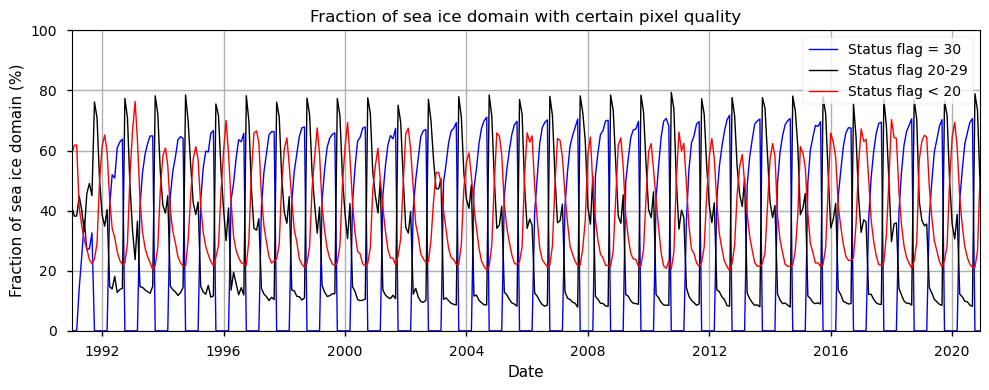

In [12]:
ice_conc_thres = 0.15

# Fraction of valid data
ds["valid_fraction"] = ds["valid_fraction"].where(ds["ice_conc"] >= ice_conc_thres)
ds["rejected_fraction"] = ds["rejected_fraction"].where(ds["ice_conc"] >= ice_conc_thres)
ds["lessquality_fraction"] = ds["lessquality_fraction"].where(ds["ice_conc"] >= ice_conc_thres)

fraction_ts = (
    100
    * ds["valid_fraction"].sum(dim=("yc", "xc"))
    / (ds["ice_conc"] >= ice_conc_thres).sum(dim=("yc", "xc"))
)
fraction_rj = (
    100
    * ds["rejected_fraction"].sum(dim=("yc", "xc"))
    / (ds["ice_conc"] >= ice_conc_thres).sum(dim=("yc", "xc"))
)
fraction_bq = (
    100
    * ds["lessquality_fraction"].sum(dim=("yc", "xc"))
    / (ds["ice_conc"] >= ice_conc_thres).sum(dim=("yc", "xc"))
)

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(ds["time"], fraction_ts, lw=1, color="blue", label="Status flag = 30")
ax.plot(ds["time"], fraction_bq, lw=1, color="black", label="Status flag 20-29")
ax.plot(ds["time"], fraction_rj, lw=1, color="red", label="Status flag < 20")

# determine valid time range
valid_times = fraction_ts.dropna("time")["time"]
ax.set_xlim(valid_times.min().values, valid_times.max().values)
ax.set_ylim(0,100)
ax.set(
    xlabel="Date",
    ylabel="Fraction of sea ice domain (%)",
    title="Fraction of sea ice domain with certain pixel quality",
)

ax.grid(True)
fig.tight_layout()
ax.legend()
plt.show()

*Figure 4. Time series of the fraction of pixels with valid data, less quality data and rejected data (at monthly-spaced temporal intervals) of the C3S Antarctic sea ice drift dataset when compared to the sea ice extent with a sea ice concentration >= 15%.*

As with the uncertainty, we observe that pixels with less quality or rejected data are especially present during the summer months. Here, data are removed (due to, for example, processing failures or missing input data), or are of less quality (the vector was, for example, retrieved using only the wind drift model or was interpolated from the neighbouring vectors). The percentage of valid satellite-derived data (i.e. `status_flag` = 30, meaning that the vector is retrieved purely from satellite observations and independent of other vectors or the free-drift model) drops to 0% during those months. 

During the winter months, the fraction of pixels with valid data quality (i.e. `status_flag` = 30) exhibits values of around 60-70% when compared to the sea ice mask, while the other 30-40% of the pixels of the sea ice mask are either of less quality or are rejected. Basically, this figure is again a visualisation of the temporal switch between the two processing modes, i.e. where the retrieval algorithm switches from satellite-based acquisition in winter to the ERA5 wind data and a free-drift model in summer.

The high temporal correlation between the uncertainty and the occurrence of pixels with a certain quality flag implies that the quality flags capture the limitations of the data. This enables users to filter the data according to their use case (e.g. by only using data classified as “nominal quality”). 

(satellite_satellite-sea-ice-drift_uncertainty-quality-flags_q02:section-3-2)=
#### 3.2 Spatial patterns of valid data retrievals

We can now also check the spatial patterns of these valid pixels. Therefore, we plot the temporal average of the valid fraction over each pixel. Let us therefore define a function that plots the 2D spatial distribution of valid pixel fractions:

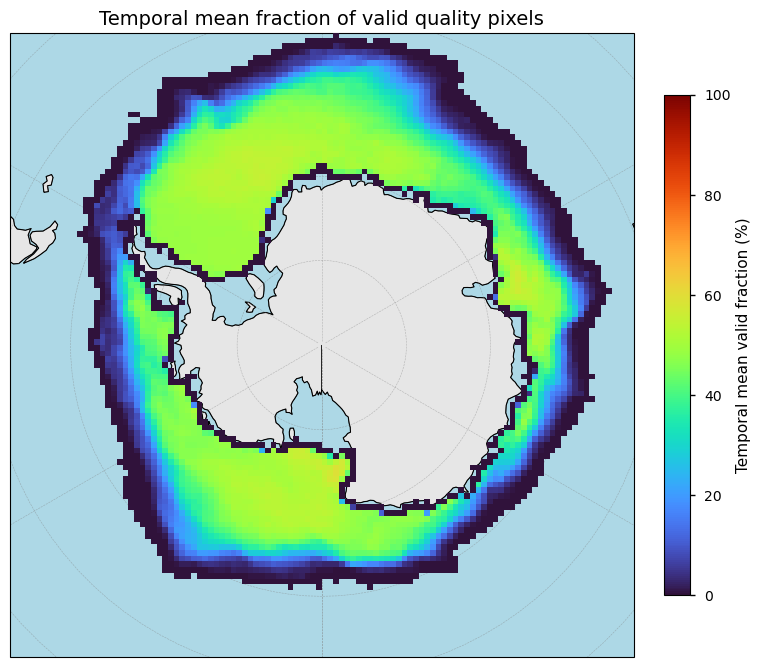

In [34]:
def plot_mean_valid_fraction_map(ds, ice_conc_thres=0.15, title=None, cmap="viridis", vmin=0, vmax=1):
    # Mask valid_fraction where sea ice concentration is below threshold
    da = ds["valid_fraction"].where(ds["ice_conc"] >= ice_conc_thres)

    # Temporal mean field
    da_mean = da.mean(dim="time", skipna=True)
    da_mean = da_mean*100

    # Coordinates (km -> m)
    x = ds["xc"].values * 1000
    y = ds["yc"].values * 1000

    # Color normalization
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    # Projection
    proj = ccrs.LambertAzimuthalEqualArea(central_longitude=0, central_latitude=-90)

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": proj})

    # Southern Ocean / Antarctic extent
    ax.set_extent([-180, 180, -90, -52.5], crs=ccrs.PlateCarree())

    # Background
    ax.add_feature(cfeature.OCEAN, facecolor="lightblue", zorder=0)
    ax.add_feature(cfeature.LAND, facecolor="0.9", edgecolor="black", zorder=1)
    ax.coastlines(linewidth=0.8, zorder=2)

    # Plot
    im = ax.pcolormesh(
        x, y, da_mean.values,
        cmap=cmap,
        norm=norm,
        transform=proj,
        shading="auto",
        zorder=3,
    )

    ax.gridlines(
        draw_labels=False,
        linewidth=0.4,
        linestyle="--",
        color="gray",
        alpha=0.5,
        zorder=100,
    )

    # Colorbar
    cb = fig.colorbar(im, ax=ax, shrink=0.65, pad=0.04)
    cb.set_label("Temporal mean valid fraction (%)")

    # Title
    if title is None:
        title = f"Temporal mean fraction of valid pixels\n(sea ice concentration ≥ {ice_conc_thres:.0%})"
    ax.set_title(title, fontsize=14)

    plt.tight_layout()
    plt.show()

plot_mean_valid_fraction_map(
    ds,
    ice_conc_thres=0.15,
    title="Temporal mean fraction of valid quality pixels",
    cmap="turbo",
    vmin=0,
    vmax=100,
)

*Figure 5. Spatial pattern of the fraction of pixels with valid data (i.e. status_flag = 30) of the C3S Antarctic sea ice drift dataset when compared to the sea ice extent with a sea ice concentration >= 15%.*

From the image above, it is especially obvious that locations too close to land or the sea ice edge exhibit difficulties during processing and often have less quality or are rejected. These vectors then often require additional processing or are removed from the data. The most reliable data therefore occur over robust, closed sea ice. With the above analysis in mind, we can thus conclude that sea ice data exhibit higher quality during the winter months and over closed sea ice regions. These data also generally exhibit lower uncertainty values. 

Let us now check where the rejected data are:

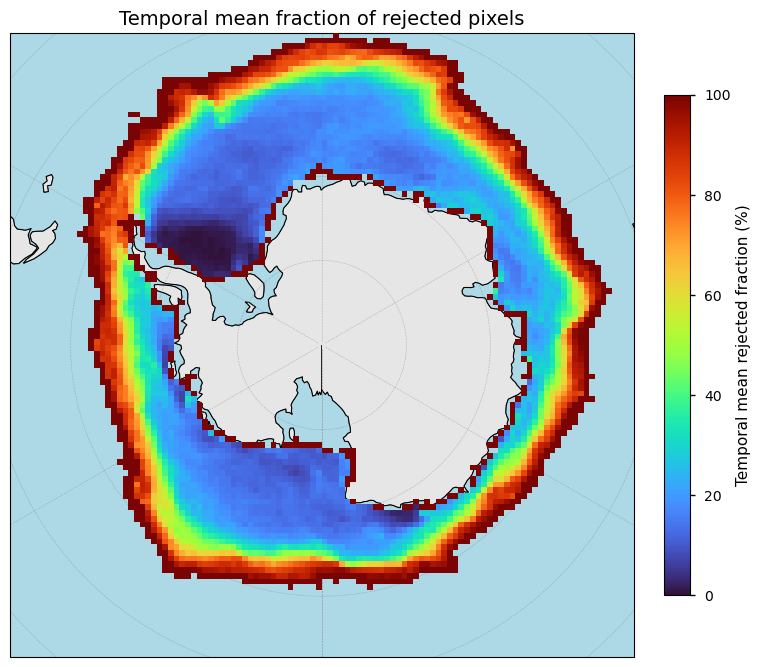

In [35]:
def plot_mean_valid_fraction_map(ds, ice_conc_thres=0.15, title=None, cmap="viridis", vmin=0, vmax=1):
    # Mask valid_fraction where sea ice concentration is below threshold
    da = ds["rejected_fraction"].where(ds["ice_conc"] >= ice_conc_thres)

    # Temporal mean field
    da_mean = da.mean(dim="time", skipna=True)
    da_mean = da_mean*100

    # Coordinates (km -> m)
    x = ds["xc"].values * 1000
    y = ds["yc"].values * 1000

    # Color normalization
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    # Projection
    proj = ccrs.LambertAzimuthalEqualArea(central_longitude=0, central_latitude=-90)

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": proj})

    # Southern Ocean / Antarctic extent
    ax.set_extent([-180, 180, -90, -52.5], crs=ccrs.PlateCarree())

    # Background
    ax.add_feature(cfeature.OCEAN, facecolor="lightblue", zorder=0)
    ax.add_feature(cfeature.LAND, facecolor="0.9", edgecolor="black", zorder=1)
    ax.coastlines(linewidth=0.8, zorder=2)

    # Plot
    im = ax.pcolormesh(
        x, y, da_mean.values,
        cmap=cmap,
        norm=norm,
        transform=proj,
        shading="auto",
        zorder=3,
    )

    ax.gridlines(
        draw_labels=False,
        linewidth=0.4,
        linestyle="--",
        color="gray",
        alpha=0.5,
        zorder=100,
    )

    # Colorbar
    cb = fig.colorbar(im, ax=ax, shrink=0.65, pad=0.04)
    cb.set_label("Temporal mean rejected fraction (%)")

    # Title
    if title is None:
        title = f"Temporal mean fraction of rejected pixels\n(sea ice concentration ≥ {ice_conc_thres:.0%})"
    ax.set_title(title, fontsize=14)

    plt.tight_layout()
    plt.show()

plot_mean_valid_fraction_map(
    ds,
    ice_conc_thres=0.15,
    title="Temporal mean fraction of rejected pixels",
    cmap="turbo",
    vmin=0,
    vmax=100,
)

*Figure 6. Spatial pattern of the fraction of pixels with rejected data (i.e. status_flag < 20) of the C3S Antarctic sea ice drift dataset when compared to the sea ice extent with a sea ice concentration >= 15%.*

Again, we note a similar pattern: data close to the sea ice edge and near the coastal regions are often rejected. These have `NaN` data in the C3S sea ice drift dataset while exhibiting a sea ice concentration of >= 15% in the C3S sea ice concentration dataset. This again implies that the provided quality flags capture the limitations that these regions pose, which are already inherently quantified by the uncertainty of the product. With this in mind, let us now further inspect the spatial and temporal trends of the sea ice drift data. 

#### 3.3 Link between uncertainty and quality flags

Let us now check the link between the uncertainty values and the quality flags. The figure below demonstrates a clear relationship between the OSI SAF pixel-quality flags and the associated sea ice drift uncertainty. Pixels that have been assigned the nominal quality flag (`status_flag` = 30) exhibit the lowest uncertainties and a relatively narrow interquartile range. In contrast, pixels with lower (`status_flag` < 30) quality flags show substantially higher and more variable uncertainties, confirming that the status flag provides a meaningful indicator of the quality of the sea ice drift product.

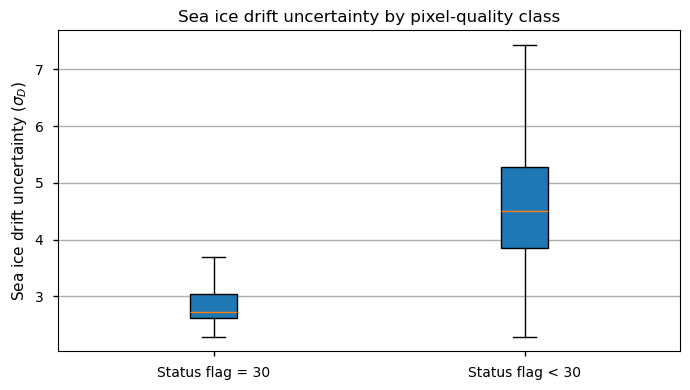

In [42]:
ice_conc_thres = 0.15

unc = ds["uncert_dX_and_dY"].where(ds["ice_conc"] >= ice_conc_thres)
flag = ds["status_flag"].where(ds["ice_conc"] >= ice_conc_thres)

unc_good = unc.where(flag == 30).values.ravel()
unc_bad  = unc.where(flag < 30).values.ravel()

# remove NaNs
unc_good = unc_good[np.isfinite(unc_good)]
unc_bad  = unc_bad[np.isfinite(unc_bad)]

data_box = [unc_good, unc_bad]

labels = [
    "Status flag = 30",
    "Status flag < 30"
]

fig, ax = plt.subplots(figsize=(7, 4))

bp = ax.boxplot(
    data_box,
    labels=labels,
    showfliers=False,
    patch_artist=True
)

ax.set_ylabel(r"Sea ice drift uncertainty ($\sigma_D$)")
ax.set_title("Sea ice drift uncertainty by pixel-quality class")
ax.grid(True, axis="y")

fig.tight_layout()
plt.show()

*Figure 7. Boxplots of sea ice drift uncertainty values ($\sigma_D$) for pixel-quality classes defined by the OSI SAF status flags.*

(satellite_satellite-sea-ice-drift_uncertainty-quality-flags_q02:section-4)=
### 4. Antarctic sea ice drift variability and trends

(satellite_satellite-sea-ice-drift_uncertainty-quality-flags_q02:section-4-1)=
#### 4.1 Spatial distribution of linear trends

With the information above in mind, we can now proceed to calculate the linear trend of sea ice drift magnitudes over each pixel in the domain. To determine whether the temporal extent of the dataset is sufficient to capture reliable spatial/temporal trends and to use these trends as indicators of climatic changes, we turn to the literature. The Intergovernmental Panel on Climate Change (IPCC) and World Meteorological Orginization (WMO) often use 30 years as a standard period for climate normals and trend analysis to ensure that the analysis captures meaningful climatic changes rather than short-term (intra/interannual) fluctuations. We therefore consider these guidelines to be likewise applicable for sea ice drift. 

Let us now plot the data below.

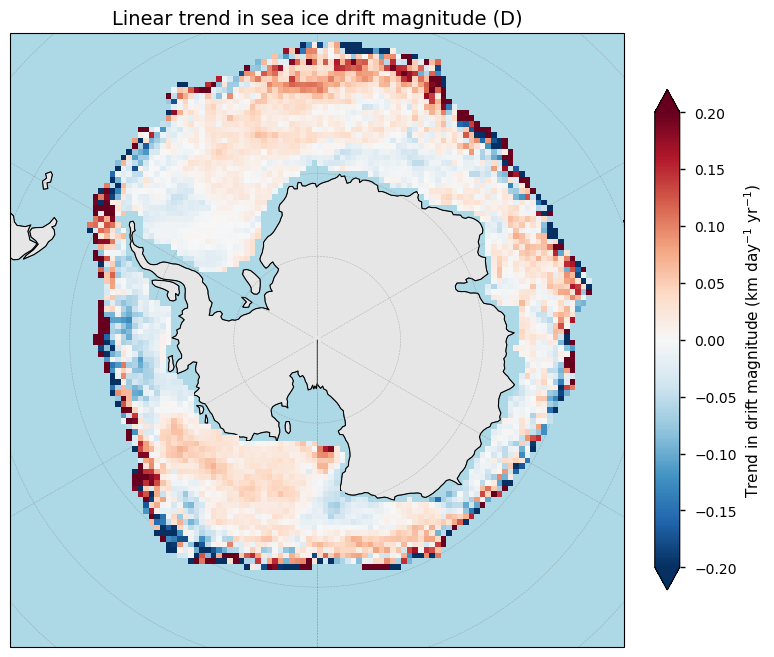

In [36]:
def plot_linear_trend_drift_magnitude(ds, title=None, cmap="RdBu_r", vmin=-0.2, vmax=0.2):
    # Drift magnitude
    da = np.sqrt(ds["dX"]**2 + ds["dY"]**2)

    # Numeric time axis in years since first time step
    t_years = (ds["time"] - ds["time"].isel(time=0)) / np.timedelta64(1, "D")
    t_years = t_years / 365.25

    # Replace datetime time coordinate by numeric years for fitting
    da_fit = da.assign_coords(time=t_years)

    # Linear trend per pixel
    pf = da_fit.polyfit(dim="time", deg=1, skipna=True)
    trend = pf["polyfit_coefficients"].sel(degree=1)

    # Coordinates in m
    x = ds["xc"].values * 1000
    y = ds["yc"].values * 1000

    # Symmetric color range around zero by default
    if vmin is None or vmax is None:
        absmax = float(np.nanmax(np.abs(trend.values)))
        vmin, vmax = -absmax, absmax

    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    # Projection
    proj = ccrs.LambertAzimuthalEqualArea(central_longitude=0, central_latitude=-90)

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": proj})
    ax.set_extent([-180, 180, -90, -52.5], crs=ccrs.PlateCarree())

    # Background
    ax.add_feature(cfeature.OCEAN, facecolor="lightblue", zorder=0)
    ax.add_feature(cfeature.LAND, facecolor="0.9", edgecolor="black", zorder=1)
    ax.coastlines(linewidth=0.8, zorder=2)

    # Trend field
    im = ax.pcolormesh(
        x, y, trend.values,
        cmap=cmap,
        norm=norm,
        transform=proj,
        shading="auto",
        zorder=3,
    )

    ax.gridlines(
        draw_labels=False,
        linewidth=0.4,
        linestyle="--",
        color="gray",
        alpha=0.5,
        zorder=100,
    )

    cb = fig.colorbar(im, ax=ax, shrink=0.65, pad=0.04, extend="both")
    cb.set_label(r"Trend in drift magnitude (km day$^{-1}$ yr$^{-1}$)")
    ax.set_title(title, fontsize=14)

    plt.tight_layout()
    plt.show()

    return trend

trend_mag = plot_linear_trend_drift_magnitude(
    ds,
    title=r"Linear trend in sea ice drift magnitude (D)",
    cmap="RdBu_r",
)

*Figure 8. Spatial distribution of linear trends of Antarctic sea ice drift data (1991-2020) from the C3S dataset.*

The figure above shows the spatial distribution of linear trends in Antarctic sea ice drift magnitude over the study period. Trends seem to vary regionally but most of the domain exhibits only weak trends with magnitudes close to zero. Larger positive and negative trends occur mainly near the sea ice edge, but the signals become more noisy in these regions. Together with the analysis of the valid pixel retrievals above, which indicated that data near the sea ice edge are often of less quality, it is therefore clear that the trends near the sea ice edge should be handled and interpreted with care. Let us briefly check the statistical significance of these trends:

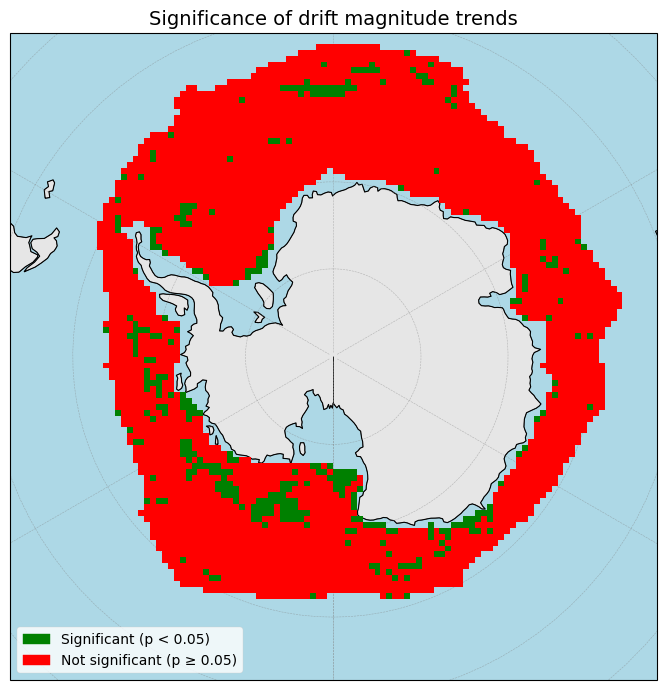

In [37]:
def plot_significance_drift_magnitude(ds, alpha=0.05, title=None):
    
    da = np.sqrt(ds["dX"]**2 + ds["dY"]**2).chunk({"time": -1})

    # Time in years
    t_years = (ds["time"] - ds["time"].isel(time=0)) / np.timedelta64(1, "D")
    t_years = (t_years / 365.25).values

    def compute_pvalue(y):
        mask = np.isfinite(y)

        if np.sum(mask) < 3:
            return np.nan

        y_valid = y[mask]
        t_valid = t_years[mask]

        if np.nanstd(y_valid) == 0:
            return np.nan

        try:
            _, _, _, p_value, _ = linregress(t_valid, y_valid)
        except:
            return np.nan

        return p_value
    
    # Apply per grid cell
    pvals = xr.apply_ufunc(
        compute_pvalue,
        da,
        input_core_dims=[["time"]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float],
    )

    significant = (pvals < alpha) & np.isfinite(pvals)

    sig_plot = xr.full_like(pvals, np.nan, dtype=float)
    sig_plot = sig_plot.where(~np.isfinite(pvals), 0.0)   # valid p-value → red by default
    sig_plot = sig_plot.where(~(pvals < alpha), 1.0)      # significant → green

    x = ds["xc"].values * 1000
    y = ds["yc"].values * 1000

    # Projection
    proj = ccrs.LambertAzimuthalEqualArea(
        central_longitude=0,
        central_latitude=-90
    )

    fig, ax = plt.subplots(
        figsize=(7, 7),
        subplot_kw={"projection": proj}
    )

    ax.set_extent([-180, 180, -90, -52.5], crs=ccrs.PlateCarree())

    # Background
    ax.add_feature(cfeature.OCEAN, facecolor="lightblue", zorder=0)
    ax.add_feature(cfeature.LAND, facecolor="0.9", edgecolor="black", zorder=1)
    ax.coastlines(linewidth=0.8, zorder=2)

    cmap = ListedColormap(["red", "green"])
    cmap.set_bad(color="none")   # NaNs are transparent / not plotted

    im = ax.pcolormesh(
        x,
        y,
        sig_plot.values,
        cmap=cmap,
        vmin=0,
        vmax=1,
        transform=proj,
        shading="auto",
        zorder=3,
    )

    # Gridlines
    ax.gridlines(
        draw_labels=False,
        linewidth=0.4,
        linestyle="--",
        color="gray",
        alpha=0.5,
        zorder=100,
    )

    red_patch = mpatches.Patch(color="red", label="Not significant (p ≥ 0.05)")
    green_patch = mpatches.Patch(color="green", label="Significant (p < 0.05)")

    ax.legend(
        handles=[green_patch, red_patch],
        loc="lower left",
        fontsize=10,
        frameon=True
    )

    if title is None:
        title = r"Statistical significance of linear trends ($\alpha = 0.05$)"

    ax.set_title(title, fontsize=14)

    plt.tight_layout()
    plt.show()

    return pvals, significant, sig_plot

# Plot
pvals, sig, sig_plot = plot_significance_drift_magnitude(
    ds,    
    alpha=0.05,    
    title="Significance of drift magnitude trends"
)

*Figure 9. Statistical significance of linear trends (1991-2020) of Antarctic sea ice drift data (at alpha = 0.05) from the C3S dataset.*

The figure shows that most linear trends of Antarctic sea ice drift are not statistically significant (red), with only small, scattered regions of significance (green). This suggests that, despite some spatial variability, the overall trend signal is weak relative to the variability, and robust long-term changes in drift magnitude are limited in extent.

(satellite_satellite-sea-ice-drift_uncertainty-quality-flags_q02:section-4-2)=
#### 4.2 Time series of sea ice drift trends

Let us now quantify the spatially averaged sea ice drift as a time series:

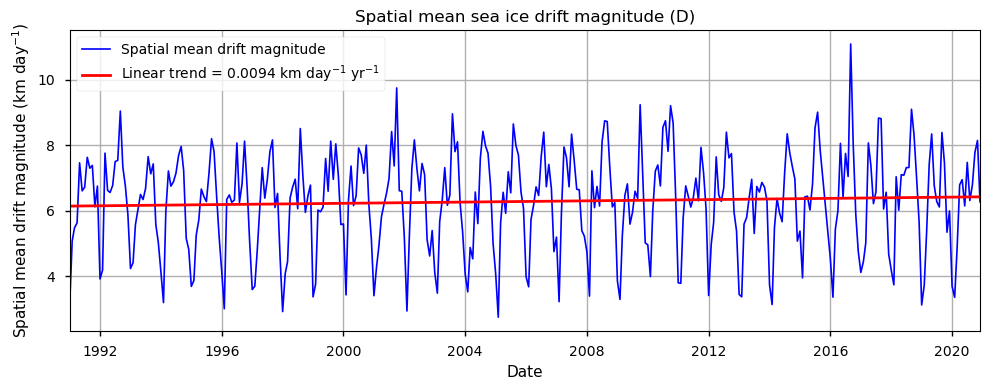

In [102]:
# Drift magnitude
drift_mag = np.sqrt(ds["dX"]**2 + ds["dY"]**2)

# Mask zero values
drift_mag = drift_mag.where(drift_mag > 0)

# Spatial average over domain
drift_mag_mean = drift_mag.mean(dim=("yc", "xc"), skipna=True)

# Numeric time in years since start
t_years = (ds["time"] - ds["time"].isel(time=0)) / np.timedelta64(1, "D")
t_years = t_years / 365.25

# Convert to numpy for fitting
x = t_years.values
y = drift_mag_mean.values

# Keep only finite values
mask = np.isfinite(x) & np.isfinite(y)
xfit = x[mask]
yfit = y[mask]

# Linear fit
slope, intercept = np.polyfit(xfit, yfit, 1)
trend_line = slope * xfit + intercept

# Plot
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ds["time"], drift_mag_mean, lw=1.2, color="blue", label="Spatial mean drift magnitude")
ax.plot(ds["time"].values[mask], trend_line, lw=2, color="red",
        label=fr"Linear trend = {slope:.4f} km day$^{{-1}}$ yr$^{{-1}}$")

ax.set(
    xlabel="Date",
    ylabel=r"Spatial mean drift magnitude (km day$^{-1}$)",
    title=r"Spatial mean sea ice drift magnitude (D)",
)
ax.grid(True)
valid_times = drift_mag_mean.dropna("time")["time"]
ax.set_xlim(valid_times.min().values, valid_times.max().values)
ax.legend()
fig.tight_layout()
plt.show()

*Figure 10. Time series and linear trend of spatially averaged Antarctic sea ice drift data (at monthly-spaced temporal intervals) from the C3S dataset.*

The spatially averaged sea ice drift magnitude shows a strong month-to-month variability throughout the period 1991–2020, with values typically varying between ca. 3 and 9 km day⁻¹. The sea ice tends to speed up during the winter months and slow down during the summer season. The fitted linear trend indicates only a small positive increase in the mean drift magnitude of approximately 0.009 km day⁻¹ yr⁻¹ over the study period. This would suggest a very slight long-term increase of the spatially averaged sea ice drift speed, but the short-term variability clearly dominates the signal in the time series. However, it is important to keep in mind the spatial and temporal fraction of valid pixel retrievals from the sections above while interpreting these data.

(satellite_satellite-sea-ice-drift_uncertainty-quality-flags_q02:section-5)=
### 5. Short summary and take-home messages

To be able to label a sea ice-related dataset as "quality rich" and for climate change analysis/monitoring to become reliable and possible, the dataset should at least exhibit a comprehensive spatial coverage (i.e. hemispheric), a long and continuous temporal coverage that allows users to detect reliable variability and trend signals (> 30 years), quantified and transparent pixel-by-pixel uncertainty estimates that meet international proposed thresholds, a validation effort or a comparison to (theoretical) models, and an adequate spatio-temporal resolution (cfr. the "Maturity Matrix" [[4](https://doi.org/10.1175/BAMS-D-21-0109.1)]). 

In that regard, the C3S sea ice drift dataset provides daily, pixel-by-pixel estimates of sea ice drift, together with associated quality flags and quantitative uncertainty estimates in the form of 1-sigma precision errors for both the Arctic and Antarctic region. In this notebook, the dataset was analysed with respect to its spatial and temporal coverage over the Antarctic region in the context of variability and trend assessments. It is found that the sea ice drift product are at this stage found to be suitable to conduct these analyses, as the temporal resolution is consistent at a daily basis and the number of consecutive years is sufficient to detect interannual variability and potential trends. However, an uncertainty and spatio-temporal coverage analysis reveals that the dataset holds regions and time periods that exhibit sea ice drift data with generally less quality. Uncertainty shows, for example, higher values at the margins and in summer. The provided quality flags capture these limitations, enabling users to filter the data according to their use case (e.g. by only using data classified as "nominal quality").

All in all, it can be stated that the C3S sea ice drift dataset is generally a mature and quality-rich dataset that allows users to capture the general state and spatio-temporal changes of sea ice motion over both polar regions. The dataset moreover allows the user to identify pixels of lesser quality and remove them if desired, further adding credibility to the quality of the dataset.

## ℹ️ If you want to know more

- "[Sea ice drift daily gridded data derived from satellite observations](https://cds.climate.copernicus.eu/datasets/satellite-sea-ice-drift?tab=overview)" on the CDS
- [Documentation on the CDS](https://cds.climate.copernicus.eu/datasets/satellite-sea-ice-drift?tab=documentation) (Copernicus Knowledge Base).
- [Copernicus climate change indicators: sea ice](https://climate.copernicus.eu/climate-indicators/sea-ice)
- [C3S EQC custom functions](https://github.com/bopen/c3s-eqc-automatic-quality-control/tree/main/c3s_eqc_automatic_quality_control), `c3s_eqc_automatic_quality_control` prepared by [B-Open](https://www.bopen.eu).

### References

- [[1](https://doi.org/10.5194/essd-15-5807-2023)] Lavergne, T. and Down, E. (2023). A climate data record of year-round global sea-ice drift from the EUMETSAT Ocean and Sea Ice Satellite Application Facility (OSI SAF), Earth Syst. Sci. Data, 15, 5807–5834, https://doi.org/10.5194/essd-15-5807-2023

- [[2](https://data.meereisportal.de/eisatlas/)] Schmitt, C., Kottmeier, Ch., Wassermann S., and Drinkwater M. (2004). Atlas of Antarctic Sea Ice Drift, Institut für Meteorologie und Klimaforschung, Universität Karlsruhe. Available from: https://data.meereisportal.de/eisatlas/
  
- [[3](https://library.wmo.int/records/item/58111-the-2022-gcos-ecvs-requirements-gcos-245)] GCOS (Global Climate Observing System) (2022). The 2022 GCOS ECVs Requirements (GCOS-245). World Meteorological Organization: Geneva, Switzerland. doi: https://library.wmo.int/idurl/4/58111

- [[4](https://doi.org/10.1175/BAMS-D-21-0109.1)] Yang, C. X., Cagnazzo, C., Artale, V., Nardelli, B. B., Buontempo, C., Busatto, J., Caporaso, L., Cesarini, C., Cionni, I., Coll, J., Crezee, B., Cristofanelli, P., de Toma, V., Essa, Y. H., Eyring, V., Fierli, F., Grant, L., Hassler, B., Hirschi, M., Huybrechts, P., Le Merle, E., Leonelli, F. E., Lin, X., Madonna, F., Mason, E., Massonnet, F., Marcos, M., Marullo, S., Muller, B., Obregon, A., Organelli, E., Palacz, A., Pascual, A., Pisano, A., Putero, D., Rana, A., Sanchez-Roman, A., Seneviratne, S. I., Serva, F., Storto, A., Thiery, W., Throne, P., Van Tricht, L., Verhaegen, Y., Volpe, G., and Santoleri, R. (2022). Independent Quality Assessment of Essential Climate Variables: Lessons Learned from the Copernicus Climate Change Service, B. Am. Meteorol. Soc., 103, E2032–E2049, https://doi.org/10.1175/Bams-D-21-0109.1 